In [1]:
# =============================================================================
# CELL 1: IMPORTS AND CONNECTION
# =============================================================================

import pandas as pd
import numpy as np
import pyodbc
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.min_rows', 40)

sns.set_theme(style='whitegrid', font_scale=1.3)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

DSN = 'Redshift_prod_new'


def run_sql(query, connection=None):
    if connection is None:
        with pyodbc.connect(f'DSN={DSN}') as conn:
            warnings.filterwarnings('ignore', category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings('default', category=UserWarning)
            return df
    else:
        warnings.filterwarnings('ignore', category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings('default', category=UserWarning)
        return df


print(f'Imports loaded, DSN={DSN}')

Imports loaded, DSN=Redshift_prod_new


In [2]:
# =============================================================================
# CELL 2: DATA FETCH
# =============================================================================

query = """
SELECT account_number,
       con_date,
       lob,
       pred_depr_rate_std,
       pred_depr_rate_std_current,
       pred_depr_rate_raw_current,
       pred_t0_adj_impound,
       pred_t0_adj_no_impound
FROM sandbox.rds_rec_model_originations
WHERE con_date >= '2022-01-01'
and con_date < '2026-07-01'
  AND pred_depr_rate_std IS NOT NULL
"""

df = run_sql(query)

df['con_date'] = pd.to_datetime(df['con_date'])
df['year'] = df['con_date'].dt.year
df['quarter'] = df['con_date'].dt.to_period('Q')
df['year_half'] = df['year'].astype(str) + ' H' + np.where(df['con_date'].dt.month <= 6, '1', '2')

print(f'Fetched {len(df):,} records')
print(f'Date range: {df.con_date.min().date()} to {df.con_date.max().date()}')
print(f'LOBs: {sorted(df.lob.unique())}')
print(f'\npred_depr_rate_std summary:')
display(df['pred_depr_rate_std_current'].describe().round(4))

Fetched 571,431 records
Date range: 2022-01-01 to 2026-06-30
LOBs: ['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'SFS', 'STG']

pred_depr_rate_std summary:


count    571431.0000
mean          0.2062
std           0.0476
min           0.0193
25%           0.1660
50%           0.2216
75%           0.2370
max           0.3605
Name: pred_depr_rate_std_current, dtype: float64

In [3]:
# =============================================================================
# CELL 3: DEFINE HIGH VS LOW DEPRECIATION (MEDIAN SPLIT)
# =============================================================================

median_depr = df['pred_depr_rate_std_current'].median()

df['depr_group'] = np.where(
    df['pred_depr_rate_std_current'] > median_depr,
    'High Depreciation',
    'Low Depreciation'
)

counts = df['depr_group'].value_counts()
pcts = df['depr_group'].value_counts(normalize=True) * 100

print(f'Median depreciation rate (cutoff): {median_depr:.4f}')
print(f'\nOverall split:')
for grp in ['Low Depreciation', 'High Depreciation']:
    print(f'  {grp}: {counts[grp]:>10,} contracts  ({pcts[grp]:.1f}%)')

print(f'\nMean depreciation rate by group:')
display(df.groupby('depr_group')['pred_depr_rate_std_current'].agg(['mean', 'median', 'std', 'min', 'max']).round(4))

Median depreciation rate (cutoff): 0.2216

Overall split:
  Low Depreciation:    286,233 contracts  (50.1%)
  High Depreciation:    285,198 contracts  (49.9%)

Mean depreciation rate by group:


,mean,median,std,min,max
depr_group,,,,,
High Depreciation,0.2425,0.237,0.0167,0.2217,0.3605
Low Depreciation,0.1701,0.166,0.0404,0.0193,0.2216


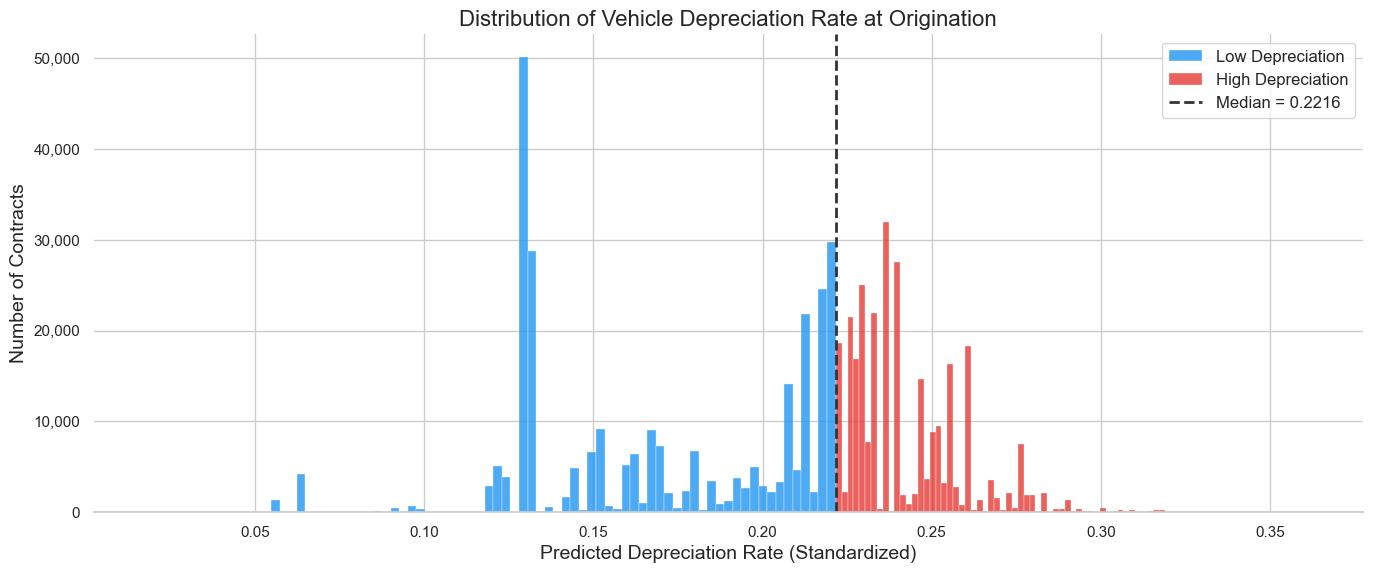

In [4]:
# =============================================================================
# CELL 4: DISTRIBUTION VISUALIZATION (OVERALL)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

low_data = df.loc[df['depr_group'] == 'Low Depreciation', 'pred_depr_rate_std_current']
high_data = df.loc[df['depr_group'] == 'High Depreciation', 'pred_depr_rate_std_current']

ax.hist(low_data, bins=80, color='#2196F3', alpha=0.8, label='Low Depreciation', edgecolor='white', linewidth=0.3)
ax.hist(high_data, bins=80, color='#E53935', alpha=0.8, label='High Depreciation', edgecolor='white', linewidth=0.3)

ax.axvline(median_depr, color='#333333', linewidth=2, linestyle='--', label=f'Median = {median_depr:.4f}')

ax.set_xlabel('Predicted Depreciation Rate (Standardized)')
ax.set_ylabel('Number of Contracts')
ax.set_title('Distribution of Vehicle Depreciation Rate at Origination')
ax.legend(fontsize=12, loc='upper right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine(left=True)

plt.tight_layout()
plt.show()

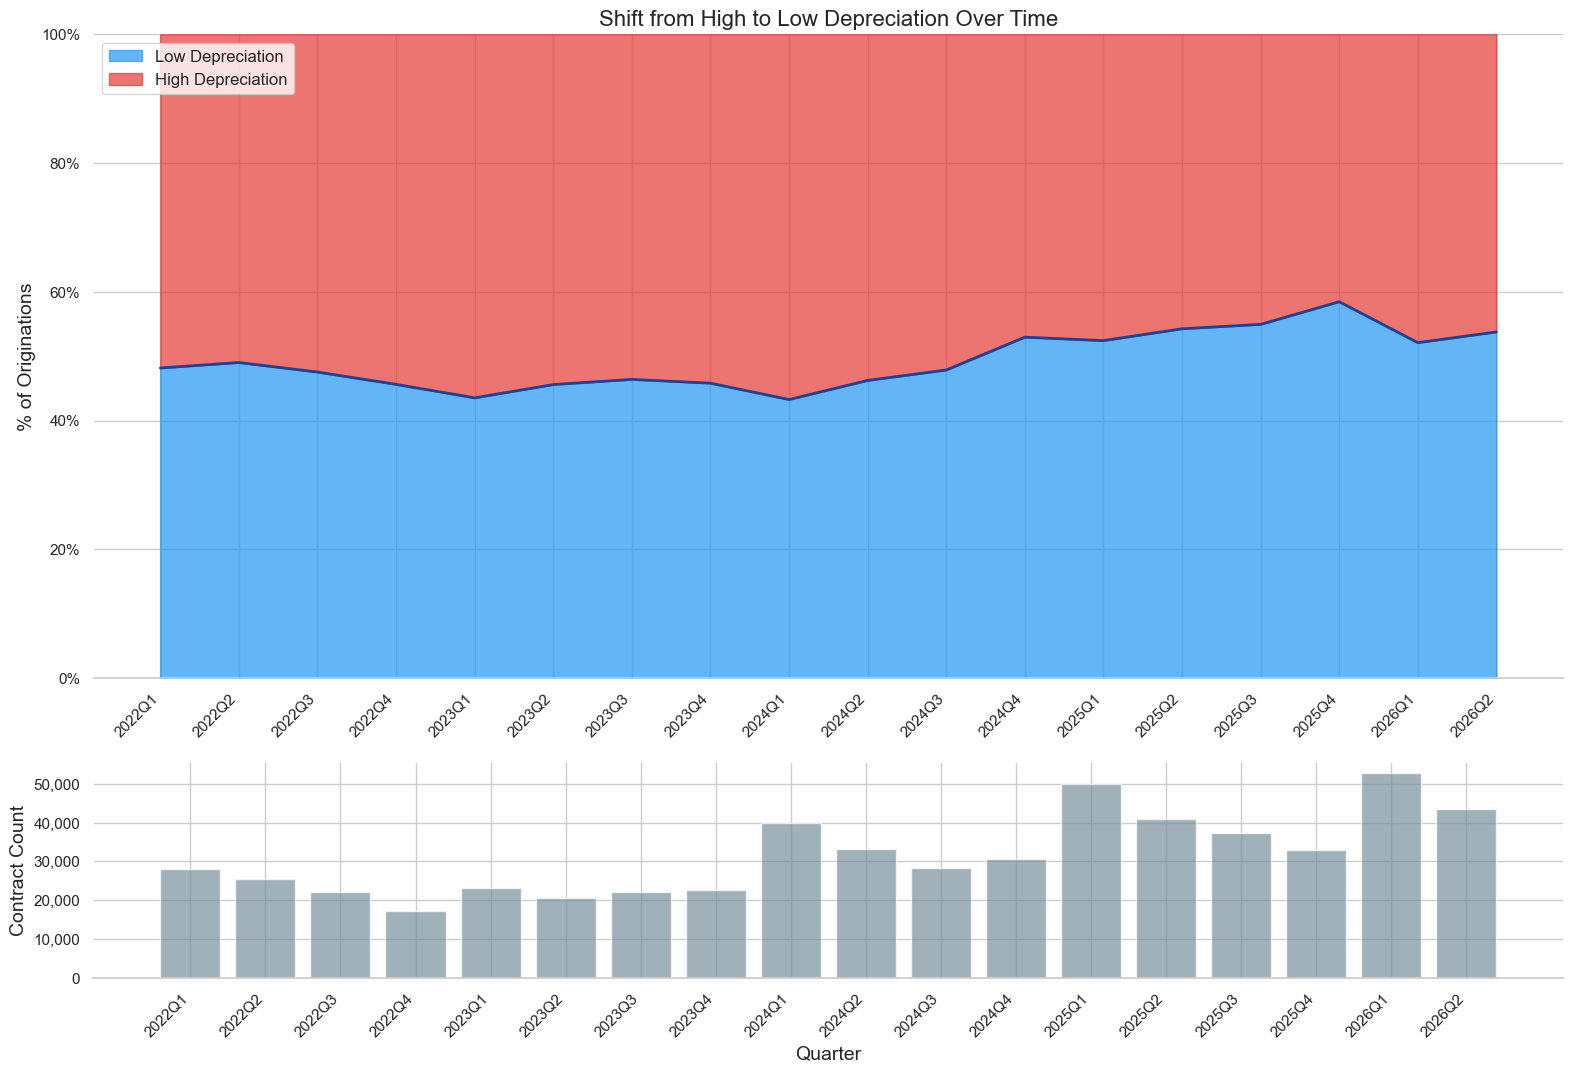

Low Depreciation share: 48.2% (2022Q1) -> 53.8% (2026Q2)
Change: +5.6 percentage points


In [5]:
# =============================================================================
# CELL 5: TIME-SERIES SHIFT (PROPORTION OVER TIME)
# =============================================================================

quarterly = (
    df.groupby(['quarter', 'depr_group'])
    .size()
    .unstack(fill_value=0)
)
quarterly_pct = quarterly.div(quarterly.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11), gridspec_kw={'height_ratios': [3, 1]})

quarters_str = quarterly_pct.index.astype(str)
x = range(len(quarters_str))

ax1.fill_between(x, quarterly_pct['Low Depreciation'], color='#2196F3', alpha=0.7, label='Low Depreciation')
ax1.fill_between(x, quarterly_pct['Low Depreciation'], 100, color='#E53935', alpha=0.7, label='High Depreciation')
ax1.plot(x, quarterly_pct['Low Depreciation'], color='#0D47A1', linewidth=2)

ax1.set_ylabel('% of Originations')
ax1.set_title('Shift from High to Low Depreciation Over Time')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=12, loc='upper left')

tick_positions = list(range(0, len(quarters_str), max(1, len(quarters_str) // 12)))
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

quarterly_count = quarterly.sum(axis=1)
ax2.bar(x, quarterly_count, color='#78909C', alpha=0.7, width=0.8)
ax2.set_ylabel('Contract Count')
ax2.set_xlabel('Quarter')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax2.set_xticks(tick_positions)
ax2.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

first_q = quarterly_pct['Low Depreciation'].iloc[0]
last_q = quarterly_pct['Low Depreciation'].iloc[-1]
print(f'Low Depreciation share: {first_q:.1f}% ({quarterly_pct.index[0]}) -> {last_q:.1f}% ({quarterly_pct.index[-1]})')
print(f'Change: {last_q - first_q:+.1f} percentage points')

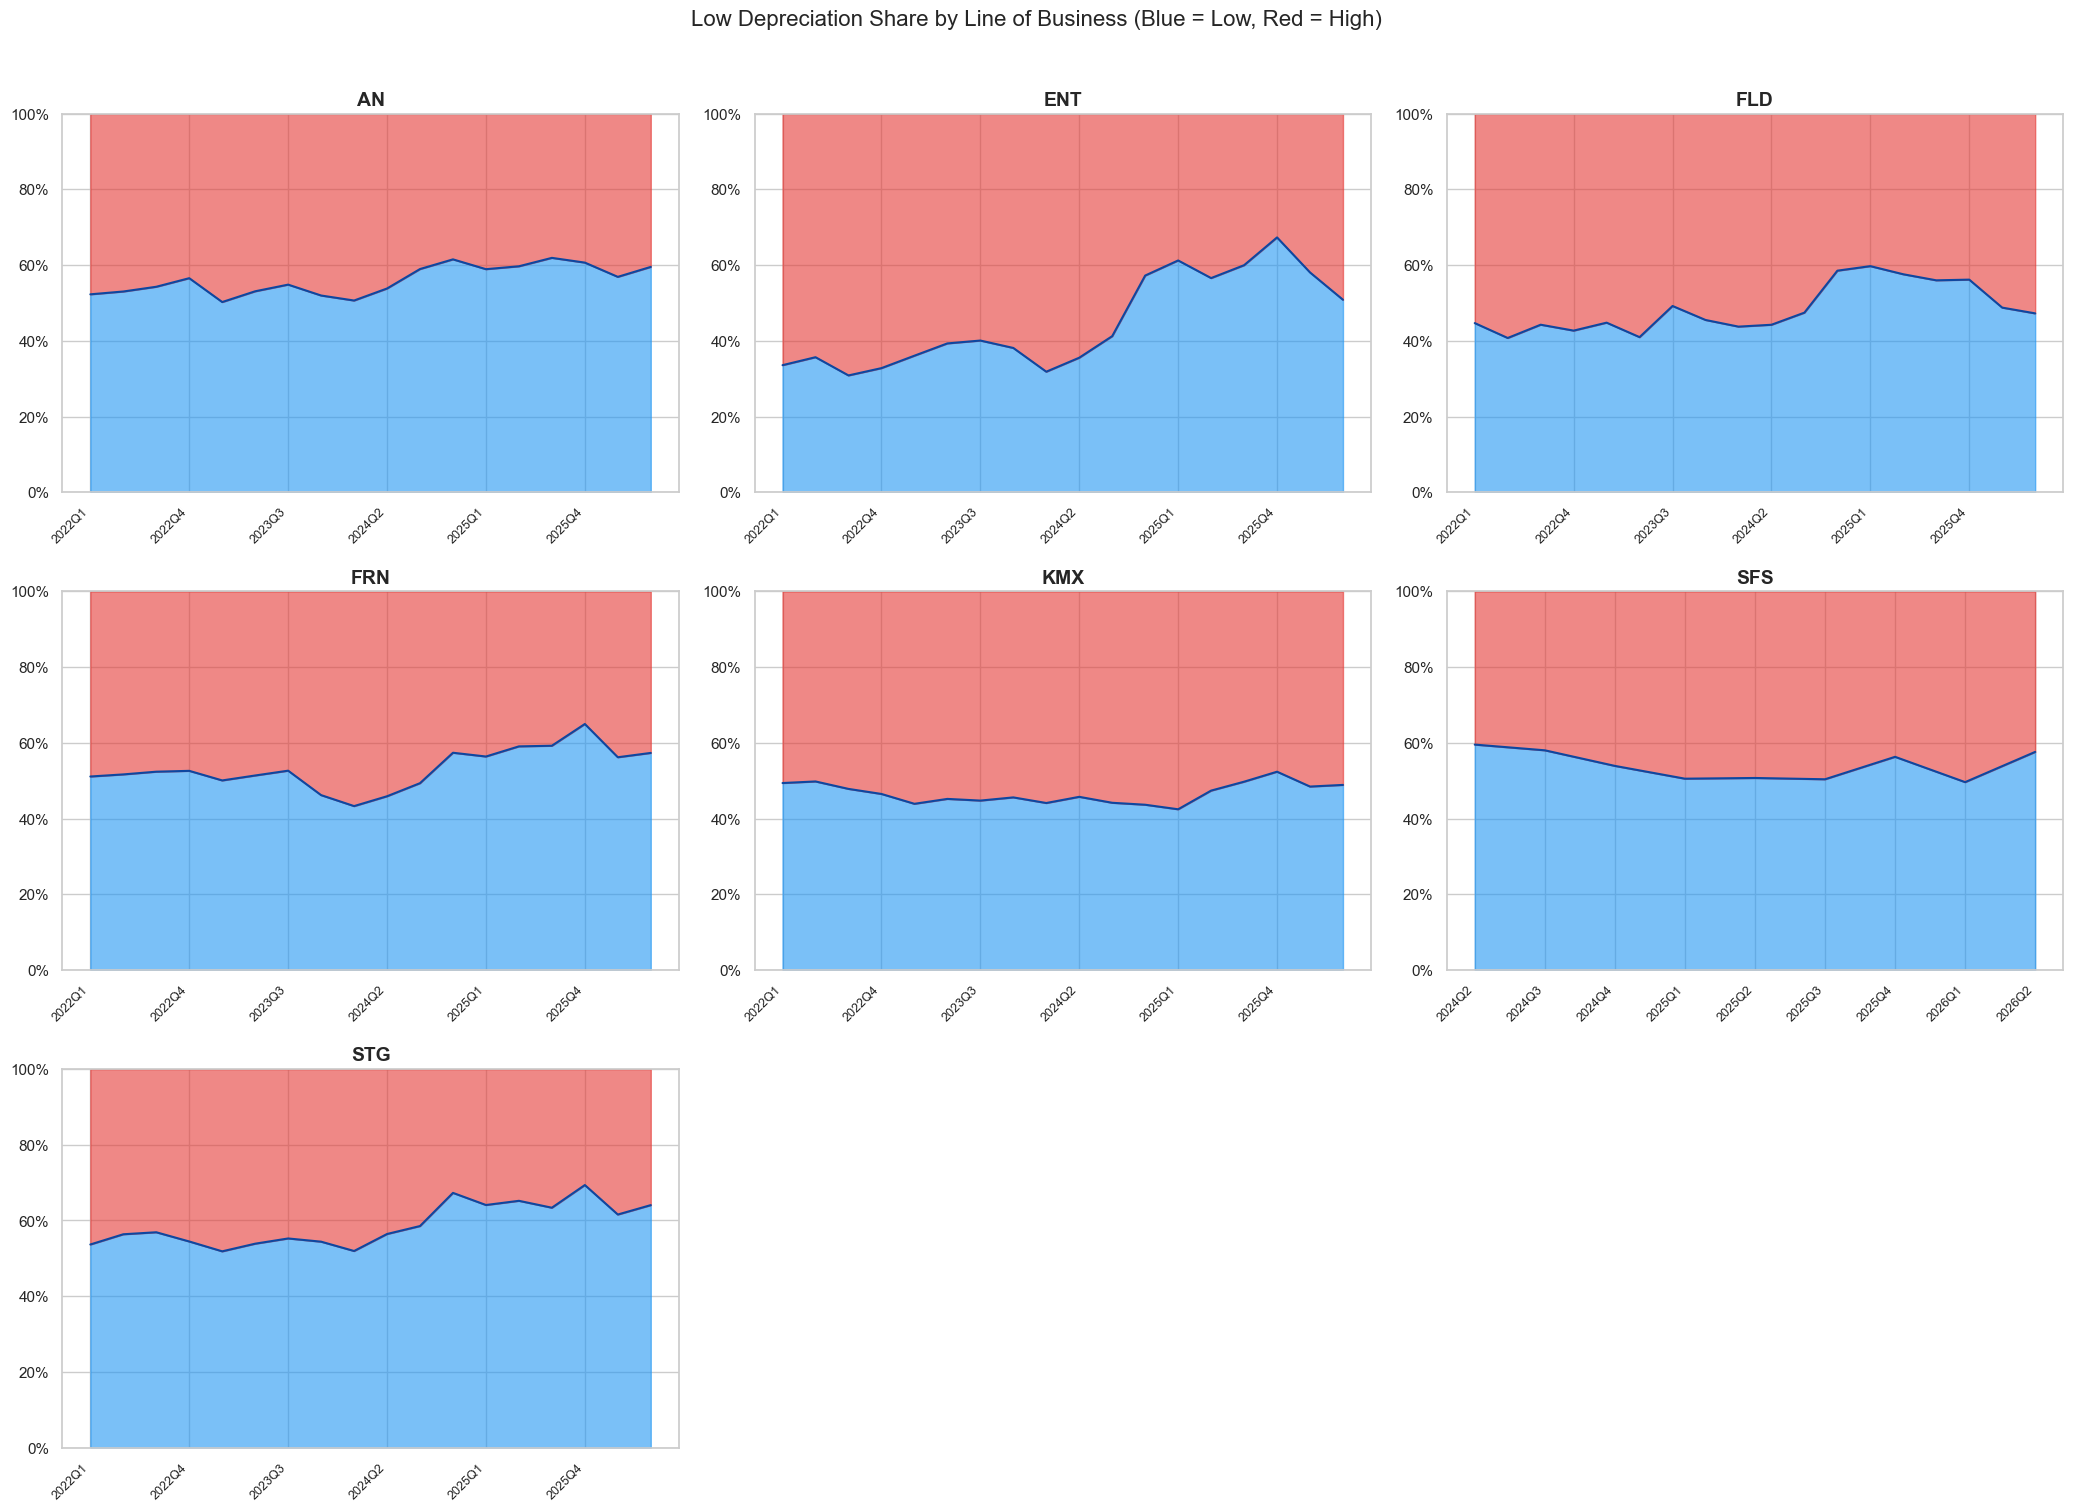

In [6]:
# =============================================================================
# CELL 6: TIME-SERIES SHIFT BY LOB
# =============================================================================

lobs_to_plot = sorted(df['lob'].unique())
n_lobs = len(lobs_to_plot)
ncols = min(3, n_lobs)
nrows = (n_lobs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)

for idx, lob in enumerate(lobs_to_plot):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    lob_df = df[df['lob'] == lob]
    lob_quarterly = (
        lob_df.groupby(['quarter', 'depr_group'])
        .size()
        .unstack(fill_value=0)
    )

    for col_name in ['Low Depreciation', 'High Depreciation']:
        if col_name not in lob_quarterly.columns:
            lob_quarterly[col_name] = 0

    lob_pct = lob_quarterly.div(lob_quarterly.sum(axis=1), axis=0) * 100
    q_str = lob_pct.index.astype(str)
    x_lob = range(len(q_str))

    ax.fill_between(x_lob, lob_pct['Low Depreciation'], color='#2196F3', alpha=0.6)
    ax.fill_between(x_lob, lob_pct['Low Depreciation'], 100, color='#E53935', alpha=0.6)
    ax.plot(x_lob, lob_pct['Low Depreciation'], color='#0D47A1', linewidth=1.5)

    ax.set_title(lob, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    ticks = list(range(0, len(q_str), max(1, len(q_str) // 5)))
    ax.set_xticks(ticks)
    ax.set_xticklabels([q_str[i] for i in ticks], rotation=45, ha='right', fontsize=9)

for idx in range(n_lobs, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].set_visible(False)

fig.suptitle('Low Depreciation Share by Line of Business (Blue = Low, Red = High)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# CELL 7: SUMMARY STATISTICS TABLE
# =============================================================================

summary = (
    df.groupby('quarter')
    .agg(
        count=('pred_depr_rate_std_current', 'size'),
        median_depr_rate=('pred_depr_rate_std_current', 'median'),
        mean_depr_rate=('pred_depr_rate_std_current', 'mean'),
        std_depr_rate=('pred_depr_rate_std_current', 'std'),
    )
)

low_counts = df[df['depr_group'] == 'Low Depreciation'].groupby('quarter').size()
summary['pct_low'] = (low_counts / summary['count'] * 100).round(1)
summary['pct_high'] = (100 - summary['pct_low']).round(1)

summary = summary[['count', 'median_depr_rate', 'mean_depr_rate', 'std_depr_rate', 'pct_low', 'pct_high']]
summary.columns = ['Contracts', 'Median Depr Rate', 'Mean Depr Rate', 'Std Dev', '% Low Depr', '% High Depr']

styled = (
    summary.style
    .format({
        'Contracts': '{:,.0f}',
        'Median Depr Rate': '{:.4f}',
        'Mean Depr Rate': '{:.4f}',
        'Std Dev': '{:.4f}',
        '% Low Depr': '{:.1f}%',
        '% High Depr': '{:.1f}%',
    })
    .bar(subset=['% Low Depr'], color='#BBDEFB', vmin=0, vmax=100)
    .bar(subset=['% High Depr'], color='#FFCDD2', vmin=0, vmax=100)
)

print(f'Cutoff (overall median): {median_depr:.4f}')
print(f'Quarters shown: {summary.index.min()} through {summary.index.max()}')
display(styled)

Cutoff (overall median): 0.2216
Quarters shown: 2022Q1 through 2026Q2


,Contracts,Median Depr Rate,Mean Depr Rate,Std Dev,% Low Depr,% High Depr
quarter,,,,,,
2022Q1,"28,004",0.2227,0.2101,0.0439,48.2%,51.8%
2022Q2,"25,521",0.2227,0.2093,0.0445,49.0%,51.0%
2022Q3,"22,214",0.2227,0.2115,0.0433,47.5%,52.5%
2022Q4,"17,319",0.2227,0.2131,0.0427,45.6%,54.4%
2023Q1,"23,158",0.2258,0.2151,0.0410,43.5%,56.5%
2023Q2,"20,670",0.2228,0.2133,0.0430,45.6%,54.4%
2023Q3,"22,163",0.2227,0.2128,0.0436,46.4%,53.6%
2023Q4,"22,617",0.2258,0.2117,0.0448,45.8%,54.2%
2024Q1,"39,827",0.2258,0.2135,0.0431,43.3%,56.7%


In [8]:
# =============================================================================
# CELL 8: INFLECTION POINT ANALYSIS
# =============================================================================

print("=== Inflection Point: Peak Low Depreciation Share ===\n")

# Overall peak
peak_q = quarterly_pct['Low Depreciation'].idxmax()
peak_val = quarterly_pct['Low Depreciation'].max()
print(f"OVERALL peak Low Depreciation quarter: {peak_q}  ({peak_val:.1f}%)\n")

# Per-LOB inflection points
print("Per-LOB peak quarters:")
print(f"{'LOB':<8} {'Peak Quarter':<20} {'Peak % Low':<12} {'Latest % Low':<14} {'Drop from Peak'}")
print("-" * 72)

lob_peaks = []
for lob in sorted(df['lob'].unique()):
    lob_df = df[df['lob'] == lob]
    lob_q = (
        lob_df.groupby(['quarter', 'depr_group'])
        .size()
        .unstack(fill_value=0)
    )
    for col_name in ['Low Depreciation', 'High Depreciation']:
        if col_name not in lob_q.columns:
            lob_q[col_name] = 0
    lob_pct = lob_q.div(lob_q.sum(axis=1), axis=0) * 100

    lob_peak_q = lob_pct['Low Depreciation'].idxmax()
    lob_peak_val = lob_pct['Low Depreciation'].max()
    lob_latest_val = lob_pct['Low Depreciation'].iloc[-1]
    drop = lob_latest_val - lob_peak_val

    lob_peaks.append({'LOB': lob, 'Peak Quarter': str(lob_peak_q),
                      'Peak % Low': lob_peak_val, 'Latest % Low': lob_latest_val})
    print(f"{lob:<8} {str(lob_peak_q):<20} {lob_peak_val:>8.1f}%     {lob_latest_val:>8.1f}%      {drop:+.1f} pp")

# Monthly granularity for more precise inflection point
df['month'] = df['con_date'].dt.to_period('M')
monthly = (
    df.groupby(['month', 'depr_group'])
    .size()
    .unstack(fill_value=0)
)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

peak_month = monthly_pct['Low Depreciation'].idxmax()
peak_month_val = monthly_pct['Low Depreciation'].max()

print(f"\n=== Monthly precision ===")
print(f"Peak month (overall): {peak_month}  ({peak_month_val:.1f}% Low Depreciation)")

# Show the months around the peak
peak_idx = monthly_pct.index.get_loc(peak_month)
window_start = max(0, peak_idx - 3)
window_end = min(len(monthly_pct), peak_idx + 4)
print(f"\nMonths around the inflection point:")
window = monthly_pct.iloc[window_start:window_end][['Low Depreciation']].copy()
window.columns = ['% Low Depreciation']
window['Contract Count'] = monthly.sum(axis=1).iloc[window_start:window_end]
display(window.round(1))

=== Inflection Point: Peak Low Depreciation Share ===

OVERALL peak Low Depreciation quarter: 2025Q4  (58.5%)

Per-LOB peak quarters:
LOB      Peak Quarter         Peak % Low   Latest % Low   Drop from Peak
------------------------------------------------------------------------
AN       2025Q3                   61.9%         59.5%      -2.4 pp
ENT      2025Q4                   67.3%         50.8%      -16.5 pp
FLD      2025Q1                   59.7%         47.2%      -12.5 pp
FRN      2025Q4                   65.0%         57.3%      -7.6 pp
KMX      2025Q4                   52.4%         48.9%      -3.5 pp
SFS      2024Q2                   59.5%         57.6%      -1.9 pp
STG      2025Q4                   69.4%         64.1%      -5.3 pp

=== Monthly precision ===
Peak month (overall): 2025-11  (58.8% Low Depreciation)

Months around the inflection point:


,% Low Depreciation,Contract Count
month,,
2025-08,54.6,12955
2025-09,54.5,12099
2025-10,58.2,12408
2025-11,58.8,10340
2025-12,58.4,10286
2026-01,54.4,12104
2026-02,51.8,18872


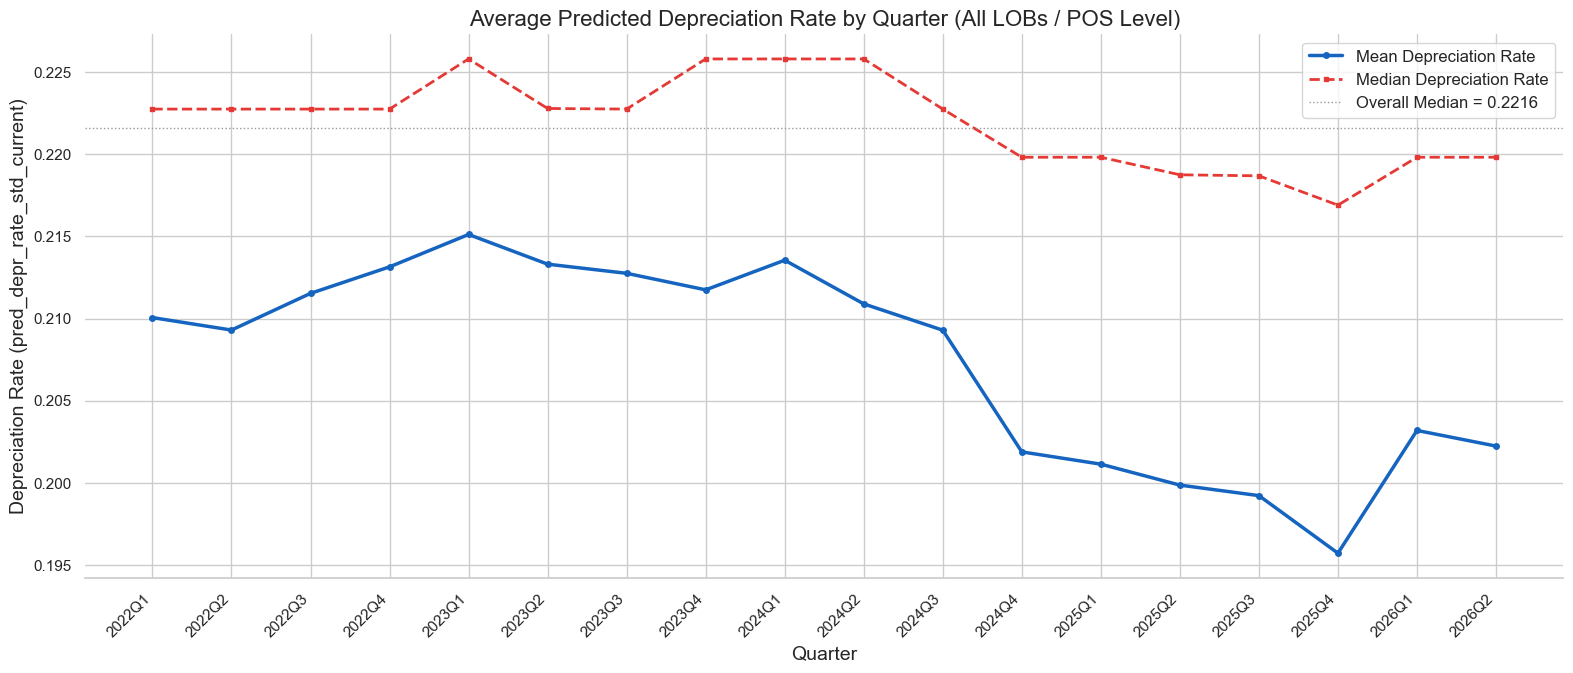


Quarterly Average Depreciation Rate (POS):


,mean_depr_rate,median_depr_rate,count
quarter,,,
2022Q1,0.2101,0.2227,"28,004"
2022Q2,0.2093,0.2227,"25,521"
2022Q3,0.2115,0.2227,"22,214"
2022Q4,0.2131,0.2227,"17,319"
2023Q1,0.2151,0.2258,"23,158"
2023Q2,0.2133,0.2228,"20,670"
2023Q3,0.2128,0.2227,"22,163"
2023Q4,0.2117,0.2258,"22,617"
2024Q1,0.2135,0.2258,"39,827"


In [9]:
# =============================================================================
# CELL 9: AVERAGE DEPRECIATION RATE BY QUARTER (POS LEVEL)
# =============================================================================

pos_quarterly = (
    df.groupby('quarter')
    .agg(
        mean_depr_rate=('pred_depr_rate_std_current', 'mean'),
        median_depr_rate=('pred_depr_rate_std_current', 'median'),
        count=('pred_depr_rate_std_current', 'size'),
    )
)

fig, ax1 = plt.subplots(figsize=(16, 7))

quarters_str = pos_quarterly.index.astype(str)
x = range(len(quarters_str))

ax1.plot(x, pos_quarterly['mean_depr_rate'], color='#1565C0', linewidth=2.5,
         marker='o', markersize=4, label='Mean Depreciation Rate')
ax1.plot(x, pos_quarterly['median_depr_rate'], color='#E53935', linewidth=2,
         linestyle='--', marker='s', markersize=3, label='Median Depreciation Rate')

ax1.axhline(median_depr, color='#999999', linewidth=1, linestyle=':', label=f'Overall Median = {median_depr:.4f}')

ax1.set_ylabel('Depreciation Rate (pred_depr_rate_std_current)')
ax1.set_xlabel('Quarter')
ax1.set_title('Average Predicted Depreciation Rate by Quarter (All LOBs / POS Level)')
ax1.legend(fontsize=12, loc='upper right')

tick_positions = list(range(0, len(quarters_str), max(1, len(quarters_str) // 12)))
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

print("\nQuarterly Average Depreciation Rate (POS):")
display(pos_quarterly.style.format({
    'mean_depr_rate': '{:.4f}',
    'median_depr_rate': '{:.4f}',
    'count': '{:,.0f}',
}))

Baseline period: 2022Q1  (28,004 contracts)
Fixed bucket cutoffs (from 2022Q1 33rd / 67th percentile):
  Low Depr:  pred_depr_rate_std_current <= 0.2114
  Mid Depr:  0.2114 < pred_depr_rate_std_current <= 0.2323
  High Depr: pred_depr_rate_std_current > 0.2323

  Low Depr:    207,893 contracts  (36.4%)
  Mid Depr:    173,876 contracts  (30.4%)
  High Depr:    189,662 contracts  (33.2%)


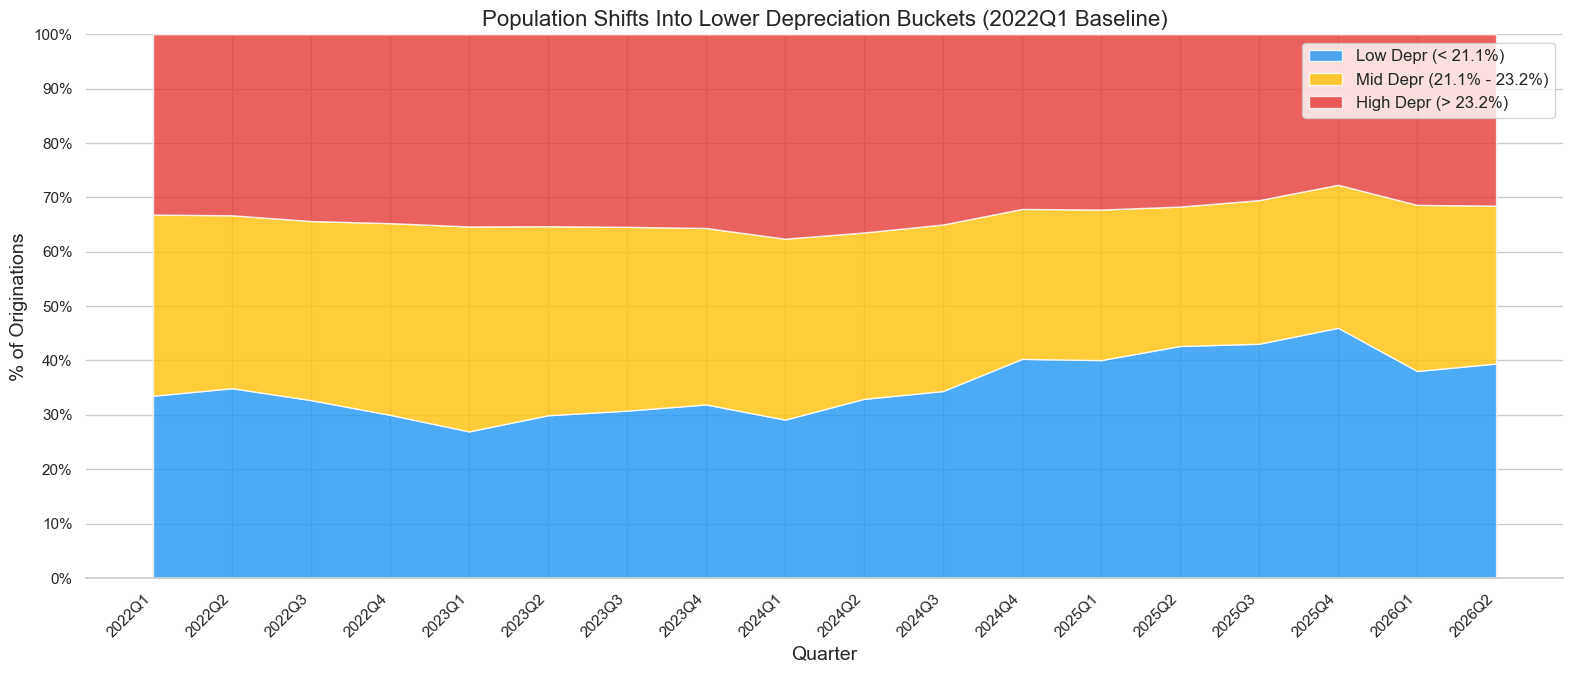


Bucket Share Migration (2022Q1 -> 2026Q2):


,2022Q1,2026Q2,Change (pp)
Bucket,,,
Low Depr (< 21.1%),33.5%,39.4%,+5.9
Mid Depr (21.1% - 23.2%),33.3%,29.0%,-4.3
High Depr (> 23.2%),33.2%,31.5%,-1.6



Quarterly Population by Bucket:


,Low Depr (count),Low Depr (%),Mid Depr (count),Mid Depr (%),High Depr (count),High Depr (%)
quarter,,,,,,
2022Q1,"9,384",33.5%,"9,330",33.3%,"9,290",33.2%
2022Q2,"8,905",34.9%,"8,118",31.8%,"8,498",33.3%
2022Q3,"7,264",32.7%,"7,318",32.9%,"7,632",34.4%
2022Q4,"5,194",30.0%,"6,108",35.3%,"6,017",34.7%
2023Q1,"6,241",26.9%,"8,729",37.7%,"8,188",35.4%
2023Q2,"6,184",29.9%,"7,188",34.8%,"7,298",35.3%
2023Q3,"6,820",30.8%,"7,492",33.8%,"7,851",35.4%
2023Q4,"7,216",31.9%,"7,341",32.5%,"8,060",35.6%
2024Q1,"11,595",29.1%,"13,255",33.3%,"14,977",37.6%


In [13]:
# =============================================================================
# CELL 10: THREE-BUCKET ANALYSIS (FIXED 2022Q1 CUTOFFS, EQUAL THIRDS)
#   Thresholds are the 33rd and 67th percentile of 2022Q1 originations.
#   Applying those fixed cutoffs to all quarters reveals genuine population
#   migration across buckets over time.
# =============================================================================

baseline = df[df['quarter'] == '2022Q1']['pred_depr_rate_std_current']
p30 = baseline.quantile(1/3)
p70 = baseline.quantile(2/3)

bucket_labels = ['Low Depr', 'Mid Depr', 'High Depr']
legend_labels = [
    f'Low Depr (< {p30:.1%})',
    f'Mid Depr ({p30:.1%} - {p70:.1%})',
    f'High Depr (> {p70:.1%})',
]

df['depr_bucket'] = pd.cut(
    df['pred_depr_rate_std_current'],
    bins=[-np.inf, p30, p70, np.inf],
    labels=bucket_labels
)

print(f"Baseline period: 2022Q1  ({len(baseline):,} contracts)")
print(f"Fixed bucket cutoffs (from 2022Q1 33rd / 67th percentile):")
print(f"  Low Depr:  pred_depr_rate_std_current <= {p30:.4f}")
print(f"  Mid Depr:  {p30:.4f} < pred_depr_rate_std_current <= {p70:.4f}")
print(f"  High Depr: pred_depr_rate_std_current > {p70:.4f}")
print()

bucket_counts = df['depr_bucket'].value_counts().sort_index()
bucket_pcts = df['depr_bucket'].value_counts(normalize=True).sort_index() * 100
for b in bucket_labels:
    print(f"  {b}: {bucket_counts[b]:>10,} contracts  ({bucket_pcts[b]:.1f}%)")

# Quarterly population by bucket
bucket_quarterly = (
    df.groupby(['quarter', 'depr_bucket'])
    .size()
    .unstack(fill_value=0)
)
bucket_quarterly_pct = bucket_quarterly.div(bucket_quarterly.sum(axis=1), axis=0) * 100

# --- Stacked area chart (proportions) ---
fig, ax1 = plt.subplots(figsize=(16, 7))

quarters_str = bucket_quarterly_pct.index.astype(str)
x = range(len(quarters_str))

colors = {'Low Depr': '#2196F3', 'Mid Depr': '#FFC107', 'High Depr': '#E53935'}

ax1.stackplot(
    x,
    bucket_quarterly_pct['Low Depr'],
    bucket_quarterly_pct['Mid Depr'],
    bucket_quarterly_pct['High Depr'],
    labels=legend_labels,
    colors=[colors[b] for b in bucket_labels],
    alpha=0.8
)

ax1.set_ylabel('% of Originations')
ax1.set_title('Population Shifts Into Lower Depreciation Buckets (2022Q1 Baseline)')
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 10))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=12, loc='upper right')

tick_positions = list(range(0, len(quarters_str), max(1, len(quarters_str) // 12)))
ax1.set_xlabel('Quarter')
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

# --- Bucket share migration table ---
first_q = bucket_quarterly_pct.index[0]
last_q = bucket_quarterly_pct.index[-1]

migration = pd.DataFrame({
    'Bucket': legend_labels,
    f'{first_q}': [f"{bucket_quarterly_pct.loc[first_q, b]:.1f}%" for b in bucket_labels],
    f'{last_q}': [f"{bucket_quarterly_pct.loc[last_q, b]:.1f}%" for b in bucket_labels],
    'Change (pp)': [f"{bucket_quarterly_pct.loc[last_q, b] - bucket_quarterly_pct.loc[first_q, b]:+.1f}" for b in bucket_labels],
}).set_index('Bucket')

print(f"\nBucket Share Migration ({first_q} -> {last_q}):")
display(migration)

print("\nQuarterly Population by Bucket:")
bucket_display = bucket_quarterly.copy()
bucket_display.columns = [f'{c} (count)' for c in bucket_display.columns]
for b in bucket_labels:
    bucket_display[f'{b} (%)'] = bucket_quarterly_pct[b].round(1)

ordered_cols = []
for b in bucket_labels:
    ordered_cols += [f'{b} (count)', f'{b} (%)']
bucket_display = bucket_display[ordered_cols]

fmt = {}
for b in bucket_labels:
    fmt[f'{b} (count)'] = '{:,.0f}'
    fmt[f'{b} (%)'] = '{:.1f}%'
display(bucket_display.style.format(fmt))

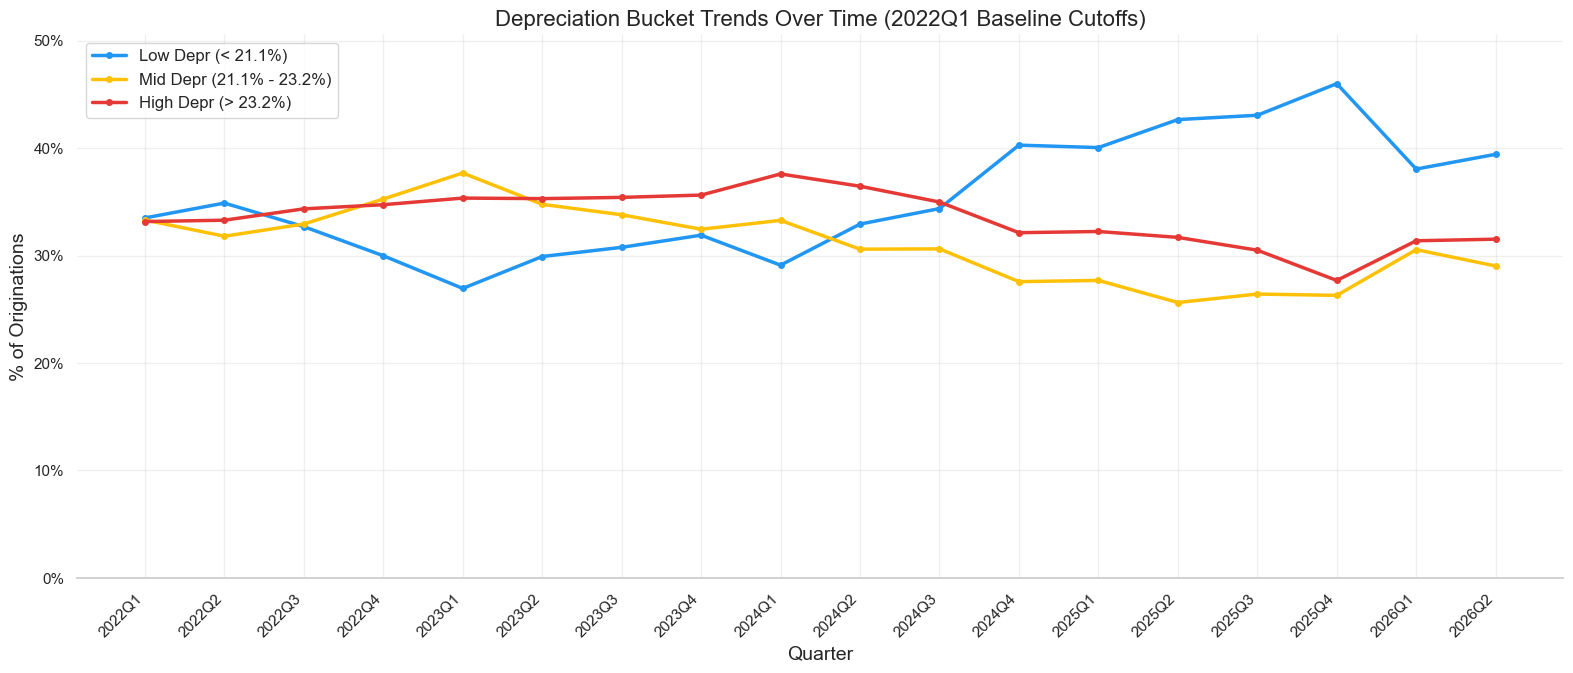

In [14]:
# =============================================================================
# CELL 10b: THREE-BUCKET LINE GRAPH (SAME DATA AS STACKED AREA)
# =============================================================================

fig, ax = plt.subplots(figsize=(16, 7))

quarters_str = bucket_quarterly_pct.index.astype(str)
x = range(len(quarters_str))

colors_line = {'Low Depr': '#2196F3', 'Mid Depr': '#FFC107', 'High Depr': '#E53935'}

for bucket, legend in zip(bucket_labels, legend_labels):
    ax.plot(x, bucket_quarterly_pct[bucket], color=colors_line[bucket],
            linewidth=2.5, marker='o', markersize=4, label=legend)

ax.set_ylabel('% of Originations')
ax.set_xlabel('Quarter')
ax.set_title('Depreciation Bucket Trends Over Time (2022Q1 Baseline Cutoffs)')
ax.set_ylim(0, bucket_quarterly_pct.values.max() * 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=12, loc='best')

tick_positions = list(range(0, len(quarters_str), max(1, len(quarters_str) // 12)))
ax.set_xticks(tick_positions)
ax.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

ax.grid(True, alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.show()

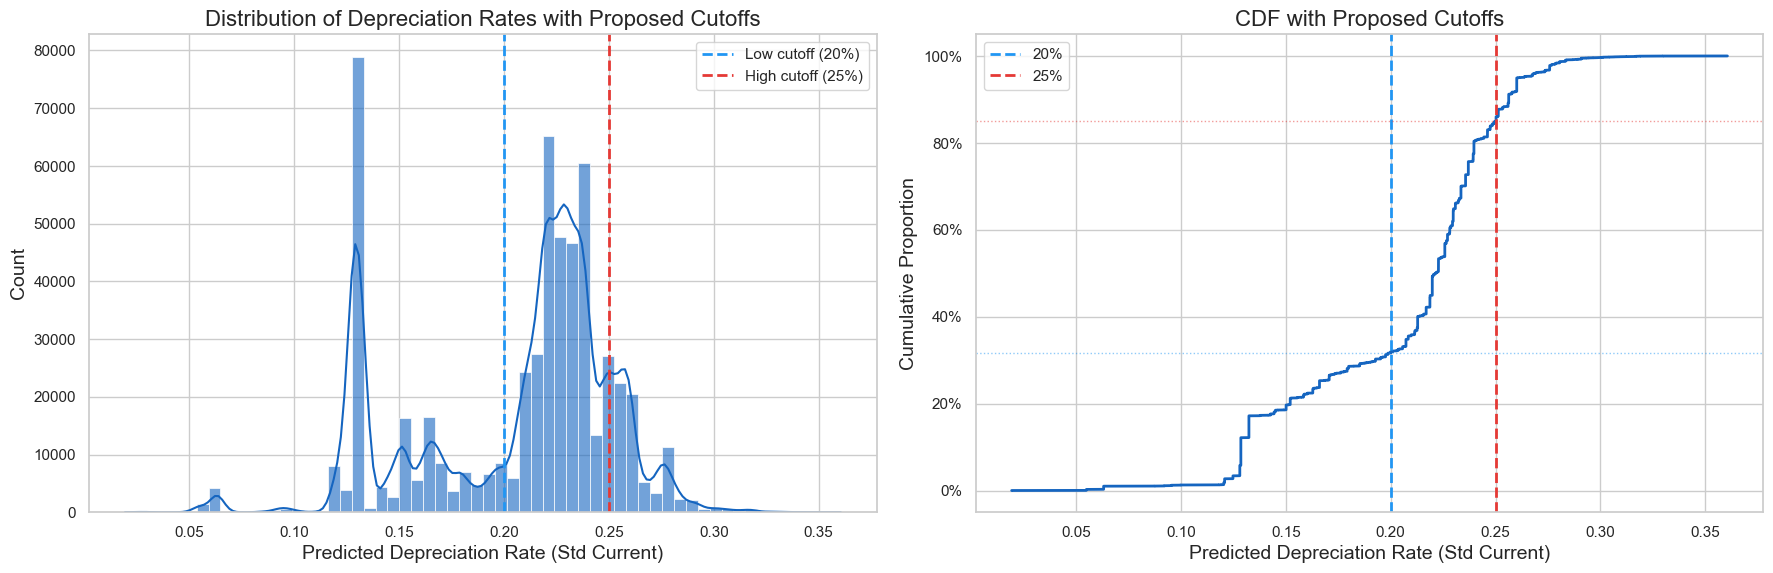

New Cutoff Definitions:
  Low Depreciation:  < 20%
  Mid Depreciation:  20% - 25%
  High Depreciation: > 25%

Overall Distribution with New Cutoffs:
  Low Depr (< 20%):    180,918 contracts  (31.7%)
  Mid Depr (20% - 25%):    304,344 contracts  (53.3%)
  High Depr (> 25%):     86,169 contracts  (15.1%)


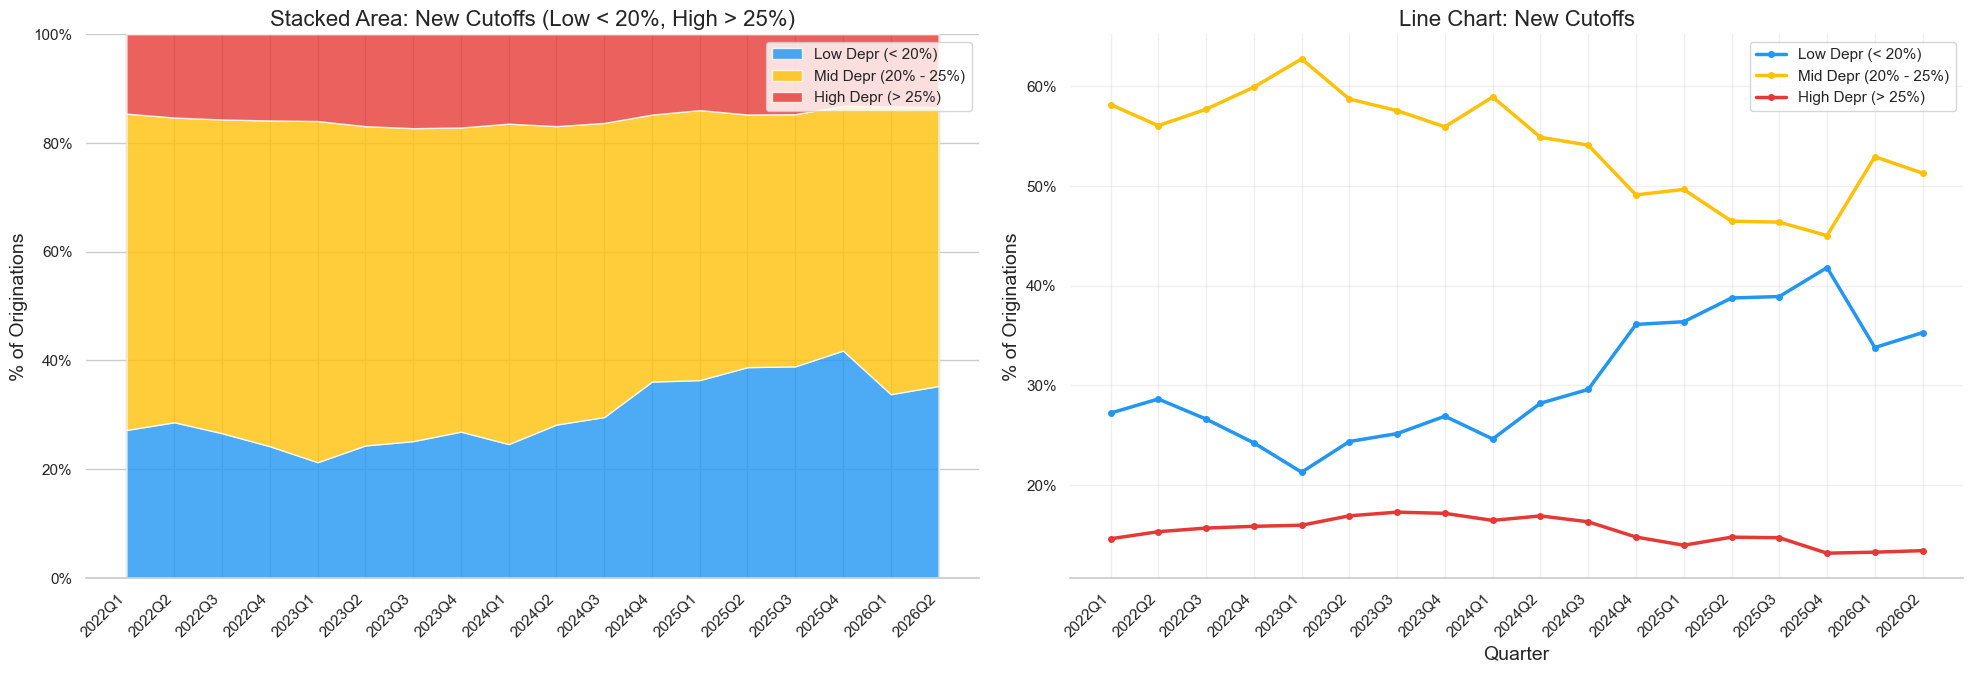


Bucket Share Migration with New Cutoffs (2022Q1 -> 2026Q2):


,2022Q1,2026Q2,Change (pp)
Bucket,,,
Low Depr (< 20%),27.2%,35.3%,+8.1
Mid Depr (20% - 25%),58.2%,51.3%,-6.9
High Depr (> 25%),14.6%,13.4%,-1.2



Quarterly Bucket Distribution (New Cutoffs: Low < 20%, High > 25%):


,Low Depr (count),Low Depr (%),Mid Depr (count),Mid Depr (%),High Depr (count),High Depr (%),Avg Depr Rate
quarter,,,,,,,
2022Q1,"7,622",27.2%,"16,292",58.2%,"4,090",14.6%,0.2101
2022Q2,"7,306",28.6%,"14,306",56.1%,"3,909",15.3%,0.2093
2022Q3,"5,913",26.6%,"12,818",57.7%,"3,483",15.7%,0.2115
2022Q4,"4,196",24.2%,"10,377",59.9%,"2,746",15.9%,0.2131
2023Q1,"4,929",21.3%,"14,532",62.8%,"3,697",16.0%,0.2151
2023Q2,"5,036",24.4%,"12,139",58.7%,"3,495",16.9%,0.2133
2023Q3,"5,576",25.2%,"12,758",57.6%,"3,829",17.3%,0.2128
2023Q4,"6,085",26.9%,"12,652",55.9%,"3,880",17.2%,0.2117
2024Q1,"9,804",24.6%,"23,472",58.9%,"6,551",16.4%,0.2135


In [37]:
# =============================================================================
# CELL 10c: DISTRIBUTION & NEW CUTOFF TESTING
#   Low Depreciation:  < 20%
#   Mid Depreciation:  20% - 25%
#   High Depreciation: > 25%
# =============================================================================

# --- Distribution of depreciation rate ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram with KDE
ax = axes[0]
sns.histplot(df['pred_depr_rate_std_current'], bins=60, kde=True, ax=ax,
             color='#1565C0', alpha=0.6, edgecolor='white', linewidth=0.5)
ax.axvline(0.20, color='#2196F3', linewidth=2, linestyle='--', label='Low cutoff (20%)')
ax.axvline(0.25, color='#E53935', linewidth=2, linestyle='--', label='High cutoff (25%)')
ax.set_xlabel('Predicted Depreciation Rate (Std Current)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Depreciation Rates with Proposed Cutoffs')
ax.legend(fontsize=11)

# CDF
ax2 = axes[1]
sorted_rates = np.sort(df['pred_depr_rate_std_current'].values)
cdf = np.arange(1, len(sorted_rates) + 1) / len(sorted_rates)
ax2.plot(sorted_rates, cdf, color='#1565C0', linewidth=2)
ax2.axvline(0.20, color='#2196F3', linewidth=2, linestyle='--', label='20%')
ax2.axvline(0.25, color='#E53935', linewidth=2, linestyle='--', label='25%')
ax2.axhline(
    (df['pred_depr_rate_std_current'] < 0.20).mean(),
    color='#2196F3', linewidth=1, linestyle=':', alpha=0.5
)
ax2.axhline(
    (df['pred_depr_rate_std_current'] < 0.25).mean(),
    color='#E53935', linewidth=1, linestyle=':', alpha=0.5
)
ax2.set_xlabel('Predicted Depreciation Rate (Std Current)')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('CDF with Proposed Cutoffs')
ax2.legend(fontsize=11)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# --- Apply new cutoff definitions ---
new_low = 0.20
new_high = 0.25

new_bucket_labels = ['Low Depr', 'Mid Depr', 'High Depr']
new_legend_labels = [
    f'Low Depr (< {new_low:.0%})',
    f'Mid Depr ({new_low:.0%} - {new_high:.0%})',
    f'High Depr (> {new_high:.0%})',
]

df['depr_bucket_new'] = pd.cut(
    df['pred_depr_rate_std_current'],
    bins=[-np.inf, new_low, new_high, np.inf],
    labels=new_bucket_labels
)

# Overall distribution
new_counts = df['depr_bucket_new'].value_counts().sort_index()
new_pcts = df['depr_bucket_new'].value_counts(normalize=True).sort_index() * 100

print(f"New Cutoff Definitions:")
print(f"  Low Depreciation:  < {new_low:.0%}")
print(f"  Mid Depreciation:  {new_low:.0%} - {new_high:.0%}")
print(f"  High Depreciation: > {new_high:.0%}")
print()
print(f"Overall Distribution with New Cutoffs:")
for b, leg in zip(new_bucket_labels, new_legend_labels):
    print(f"  {leg}: {new_counts[b]:>10,} contracts  ({new_pcts[b]:.1f}%)")

# Quarterly population by new bucket
new_bucket_quarterly = (
    df.groupby(['quarter', 'depr_bucket_new'])
    .size()
    .unstack(fill_value=0)
)
new_bucket_quarterly_pct = new_bucket_quarterly.div(new_bucket_quarterly.sum(axis=1), axis=0) * 100

# --- Stacked area chart with new cutoffs ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

quarters_str = new_bucket_quarterly_pct.index.astype(str)
x = range(len(quarters_str))
colors_new = {'Low Depr': '#2196F3', 'Mid Depr': '#FFC107', 'High Depr': '#E53935'}

ax1.stackplot(
    x,
    new_bucket_quarterly_pct['Low Depr'],
    new_bucket_quarterly_pct['Mid Depr'],
    new_bucket_quarterly_pct['High Depr'],
    labels=new_legend_labels,
    colors=[colors_new[b] for b in new_bucket_labels],
    alpha=0.8
)
ax1.set_ylabel('% of Originations')
ax1.set_title('Stacked Area: New Cutoffs (Low < 20%, High > 25%)')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=11, loc='upper right')
tick_positions = list(range(0, len(quarters_str), max(1, len(quarters_str) // 10)))
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')

# Line chart with new cutoffs
for bucket, legend in zip(new_bucket_labels, new_legend_labels):
    ax2.plot(x, new_bucket_quarterly_pct[bucket], color=colors_new[bucket],
             linewidth=2.5, marker='o', markersize=4, label=legend)
ax2.set_ylabel('% of Originations')
ax2.set_xlabel('Quarter')
ax2.set_title('Line Chart: New Cutoffs')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=11, loc='best')
ax2.set_xticks(tick_positions)
ax2.set_xticklabels([quarters_str[i] for i in tick_positions], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# --- Migration table: new cutoffs ---
first_q = new_bucket_quarterly_pct.index[0]
last_q = new_bucket_quarterly_pct.index[-1]

migration_new = pd.DataFrame({
    'Bucket': new_legend_labels,
    f'{first_q}': [f"{new_bucket_quarterly_pct.loc[first_q, b]:.1f}%" for b in new_bucket_labels],
    f'{last_q}': [f"{new_bucket_quarterly_pct.loc[last_q, b]:.1f}%" for b in new_bucket_labels],
    'Change (pp)': [f"{new_bucket_quarterly_pct.loc[last_q, b] - new_bucket_quarterly_pct.loc[first_q, b]:+.1f}" for b in new_bucket_labels],
}).set_index('Bucket')

print(f"\nBucket Share Migration with New Cutoffs ({first_q} -> {last_q}):")
display(migration_new)

# --- Full quarterly data table ---
print("\nQuarterly Bucket Distribution (New Cutoffs: Low < 20%, High > 25%):")
quarterly_display = new_bucket_quarterly.copy()
quarterly_display.columns = [f'{c} (count)' for c in quarterly_display.columns]
for b in new_bucket_labels:
    quarterly_display[f'{b} (%)'] = new_bucket_quarterly_pct[b].round(1)

# Add average depreciation rate by quarter (regardless of bucket)
quarterly_display['Avg Depr Rate'] = df.groupby('quarter')['pred_depr_rate_std_current'].mean()

ordered_cols = []
for b in new_bucket_labels:
    ordered_cols += [f'{b} (count)', f'{b} (%)']
ordered_cols.append('Avg Depr Rate')
quarterly_display = quarterly_display[ordered_cols]

fmt = {}
for b in new_bucket_labels:
    fmt[f'{b} (count)'] = '{:,.0f}'
    fmt[f'{b} (%)'] = '{:.1f}%'
fmt['Avg Depr Rate'] = '{:.4f}'
display(quarterly_display.style.format(fmt))

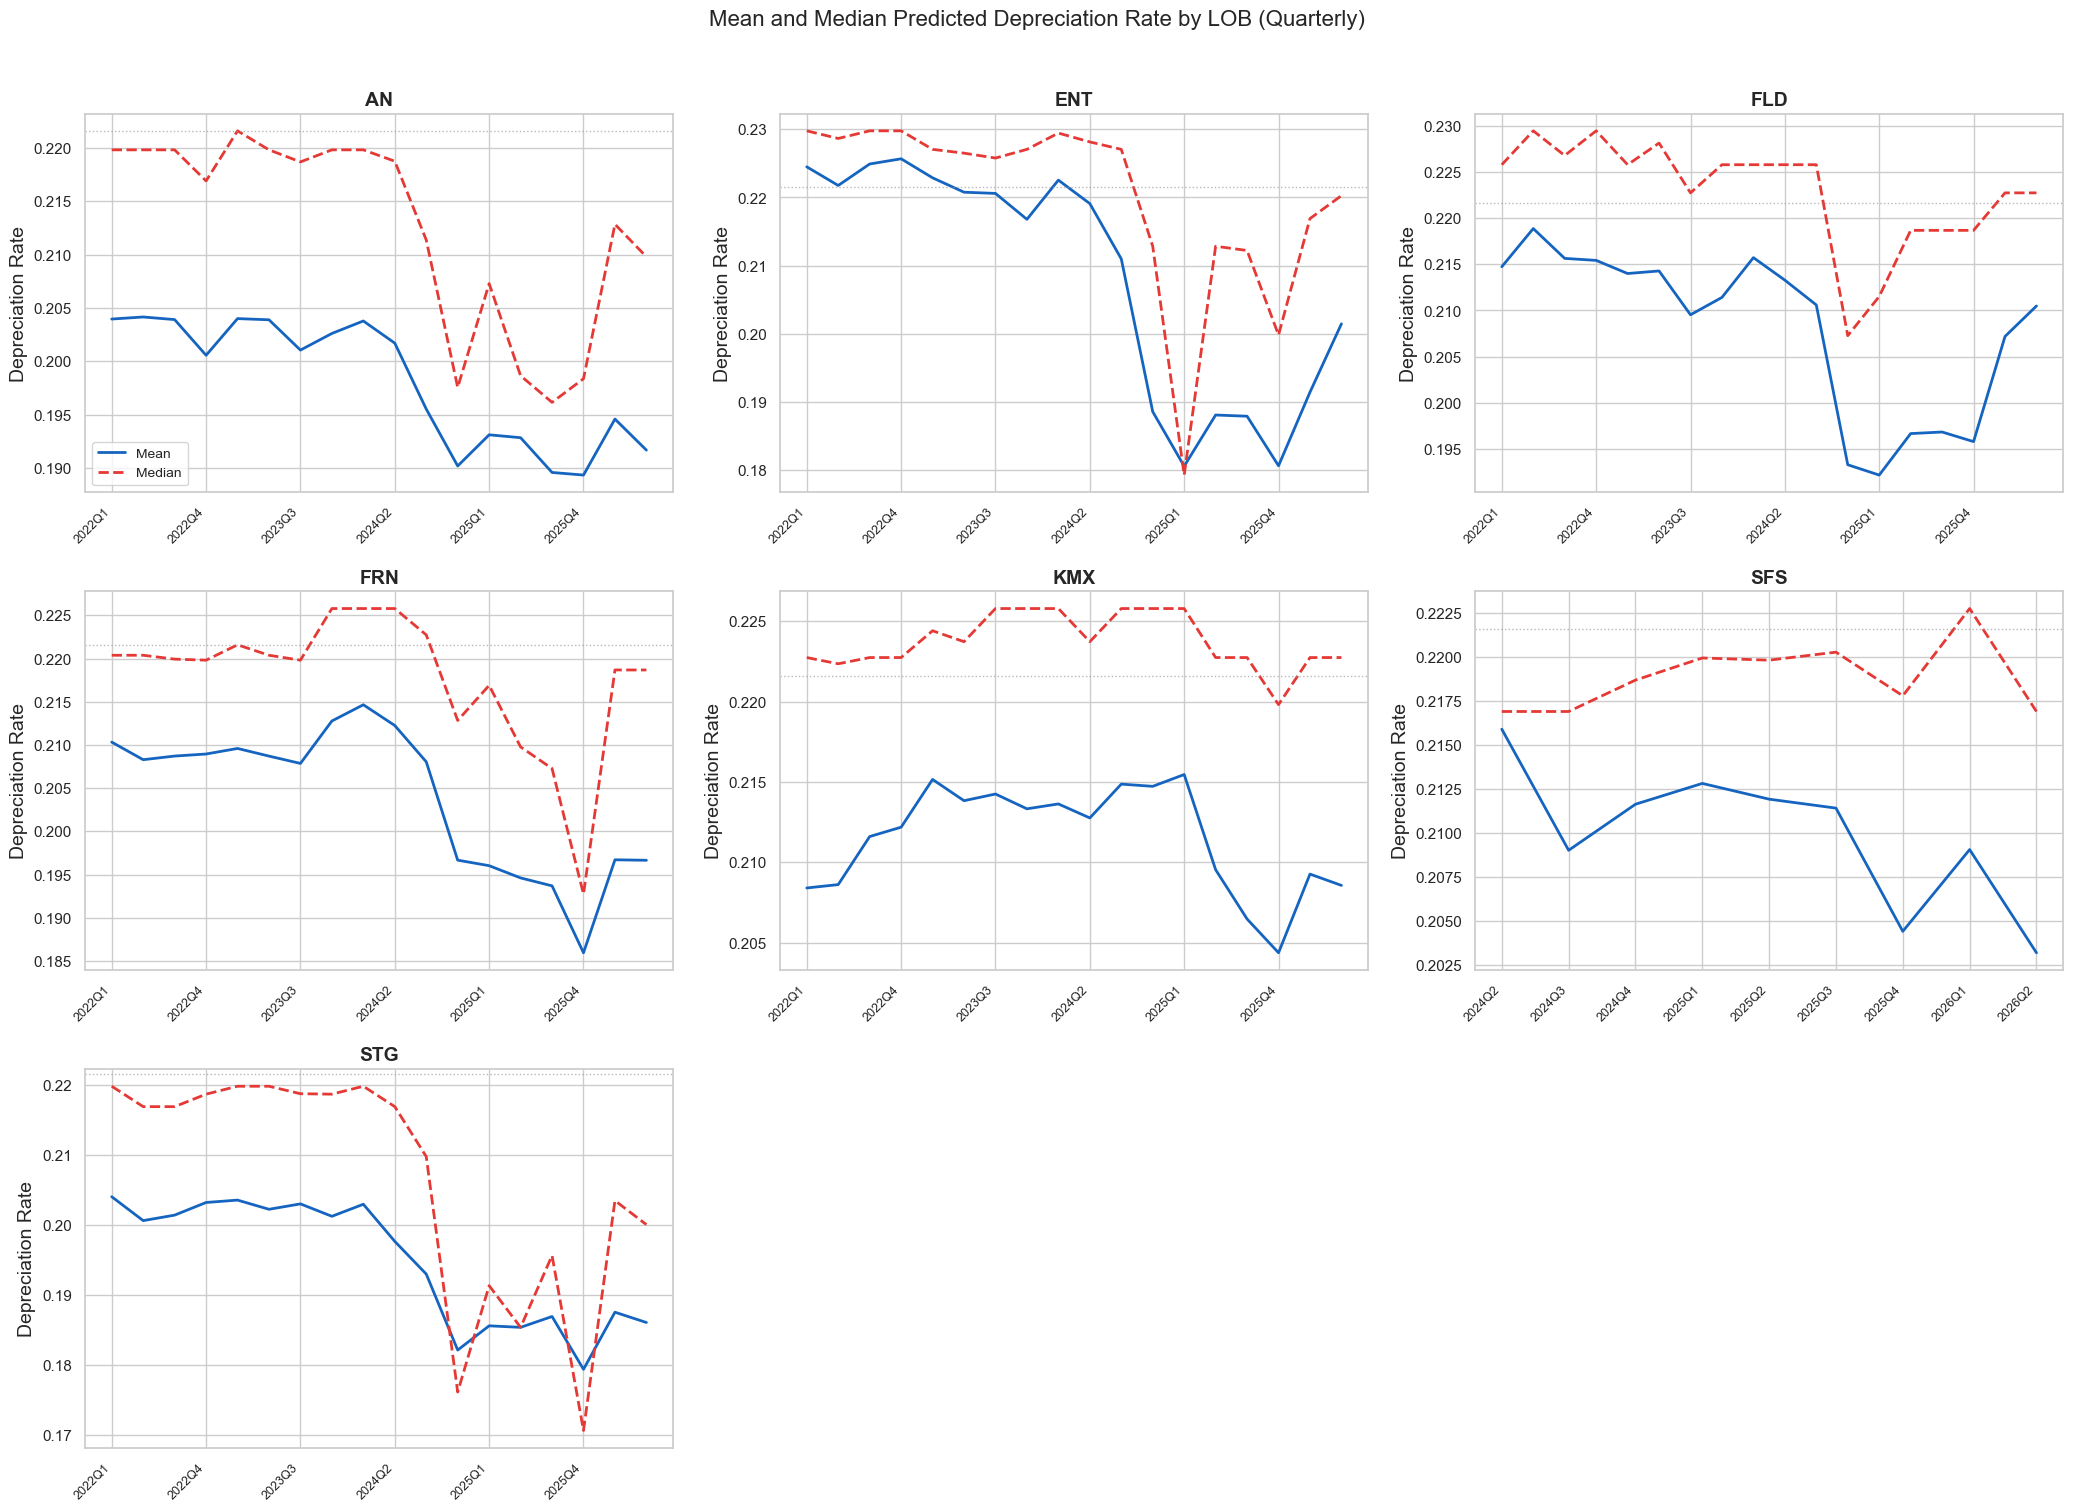

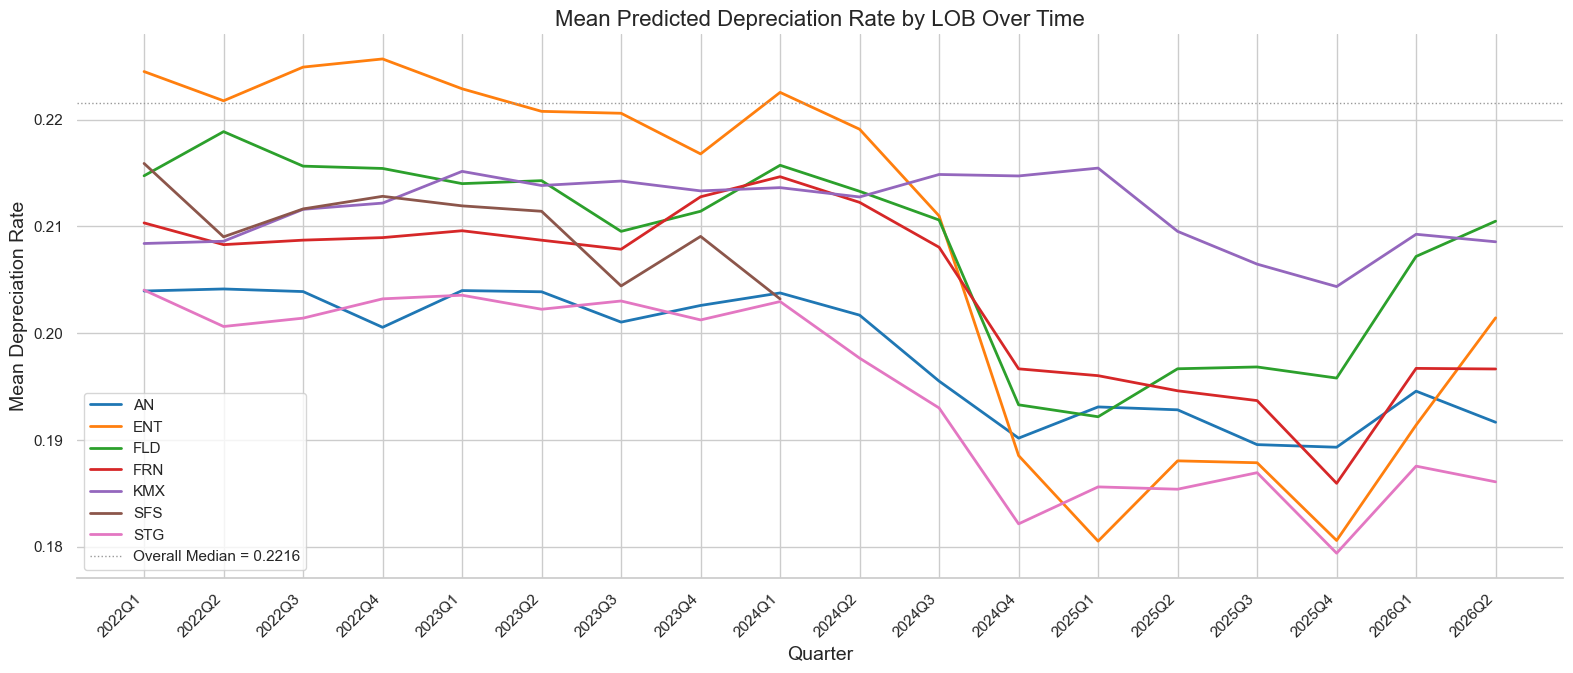

In [11]:
# =============================================================================
# CELL 11: AVERAGE AND MEDIAN DEPRECIATION RATE BY LOB OVER TIME
# =============================================================================

lobs_to_plot = sorted(df['lob'].unique())
n_lobs = len(lobs_to_plot)
ncols = min(3, n_lobs)
nrows = (n_lobs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)

for idx, lob in enumerate(lobs_to_plot):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    lob_stats = (
        df[df['lob'] == lob]
        .groupby('quarter')['pred_depr_rate_std_current']
        .agg(['mean', 'median'])
    )

    q_str = lob_stats.index.astype(str)
    x_lob = range(len(q_str))

    ax.plot(x_lob, lob_stats['mean'], color='#1565C0', linewidth=2, label='Mean')
    ax.plot(x_lob, lob_stats['median'], color='#E53935', linewidth=2, linestyle='--', label='Median')
    ax.axhline(median_depr, color='#999999', linewidth=1, linestyle=':', alpha=0.7)

    ax.set_title(lob, fontsize=14, fontweight='bold')
    ax.set_ylabel('Depreciation Rate')

    ticks = list(range(0, len(q_str), max(1, len(q_str) // 5)))
    ax.set_xticks(ticks)
    ax.set_xticklabels([q_str[i] for i in ticks], rotation=45, ha='right', fontsize=9)

    if idx == 0:
        ax.legend(fontsize=10)

for idx in range(n_lobs, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].set_visible(False)

fig.suptitle('Mean and Median Predicted Depreciation Rate by LOB (Quarterly)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Combined overlay
fig, ax = plt.subplots(figsize=(16, 7))
palette = sns.color_palette('tab10', n_colors=n_lobs)

for idx, lob in enumerate(lobs_to_plot):
    lob_stats = (
        df[df['lob'] == lob]
        .groupby('quarter')['pred_depr_rate_std_current']
        .mean()
    )
    q_str = lob_stats.index.astype(str)
    ax.plot(range(len(q_str)), lob_stats.values, linewidth=2, label=lob, color=palette[idx])

ax.axhline(median_depr, color='#999999', linewidth=1, linestyle=':', label=f'Overall Median = {median_depr:.4f}')
ax.set_ylabel('Mean Depreciation Rate')
ax.set_xlabel('Quarter')
ax.set_title('Mean Predicted Depreciation Rate by LOB Over Time')
ax.legend(fontsize=11, loc='best')

all_quarters = sorted(df['quarter'].unique())
q_labels = [str(q) for q in all_quarters]
tick_positions = list(range(0, len(q_labels), max(1, len(q_labels) // 12)))
ax.set_xticks(tick_positions)
ax.set_xticklabels([q_labels[i] for i in tick_positions], rotation=45, ha='right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

Records with all 3 metrics (2022+): 571,431

--- Summary Statistics (simple average) ---
Metric                           Std (prod)  Std Current  Raw Current
----------------------------------------------------------------------
  mean                               0.2026       0.2062       0.2256
  median                             0.2176       0.2216       0.2406
  std                                0.0474       0.0476       0.0464
  min                                0.0193       0.0193       0.0432
  max                                0.3584       0.3605       0.3761

--- Correlation Matrix ---


,pred_depr_rate_std,pred_depr_rate_std_current,pred_depr_rate_raw_current
pred_depr_rate_std,1.0000,0.9862,0.9862
pred_depr_rate_std_current,0.9862,1.0000,1.0000
pred_depr_rate_raw_current,0.9862,1.0000,1.0000


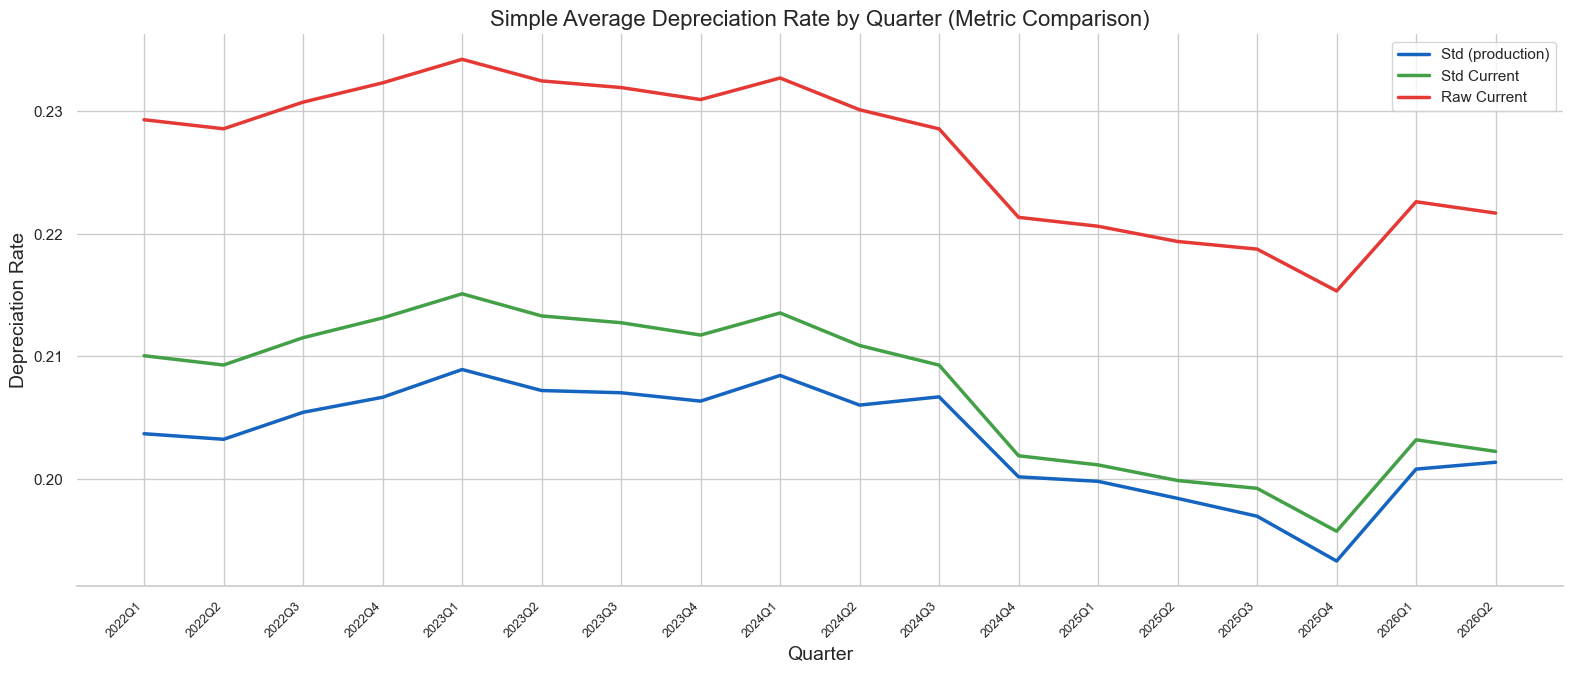


Quarterly Depreciation Rates: Simple Average by Metric


,Std (production),Std Current,Raw Current
quarter,,,
2022Q1,0.2037,0.2101,0.2293
2022Q2,0.2032,0.2093,0.2286
2022Q3,0.2054,0.2115,0.2308
2022Q4,0.2067,0.2131,0.2323
2023Q1,0.2089,0.2151,0.2343
2023Q2,0.2072,0.2133,0.2325
2023Q3,0.2070,0.2128,0.2320
2023Q4,0.2064,0.2117,0.2310
2024Q1,0.2084,0.2135,0.2327


In [12]:
# =============================================================================
# CELL 12: STD vs RAW vs STD_CURRENT DEPRECIATION RATE COMPARISON
#           Simple average by quarter (2022+) -- kept for reference
# =============================================================================

cols = ['pred_depr_rate_std', 'pred_depr_rate_std_current', 'pred_depr_rate_raw_current']
labels = ['Std (production)', 'Std Current', 'Raw Current']
colors_3 = ['#1565C0', '#43A047', '#E53935']

compare_df = df[df[cols].notna().all(axis=1)].copy()
compare_df = compare_df[compare_df['quarter'] >= '2022Q1']

print(f"Records with all 3 metrics (2022+): {len(compare_df):,}")

# --- Summary Statistics ---
print(f"\n--- Summary Statistics (simple average) ---")
print(f"{'Metric':<30} {'Std (prod)':>12} {'Std Current':>12} {'Raw Current':>12}")
print("-" * 70)
for stat in ['mean', '50%', 'std', 'min', 'max']:
    vals = [compare_df[c].describe()[stat] for c in cols]
    label = 'median' if stat == '50%' else stat
    print(f"  {label:<28} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>12.4f}")

print(f"\n--- Correlation Matrix ---")
display(compare_df[cols].corr().round(4))


# --- Build quarterly comparison: simple average only ---
quarterly_simple = compare_df.groupby('quarter')[cols].mean()

q_str = quarterly_simple.index.astype(str)
x = range(len(q_str))

# --- Chart: Simple average (all 3 metrics) ---
fig, ax = plt.subplots(figsize=(16, 7))

for col, label, color in zip(cols, labels, colors_3):
    ax.plot(x, quarterly_simple[col], color=color, linewidth=2.5, label=label)
ax.set_ylabel('Depreciation Rate')
ax.set_xlabel('Quarter')
ax.set_title('Simple Average Depreciation Rate by Quarter (Metric Comparison)')
ax.legend(fontsize=11)
ax.set_xticks(range(len(q_str)))
ax.set_xticklabels(q_str, rotation=45, ha='right', fontsize=9)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\nQuarterly Depreciation Rates: Simple Average by Metric")
summary_tbl = quarterly_simple.copy()
summary_tbl.columns = labels

display(summary_tbl.style.format('{:.4f}'))